# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "./02_mini4oLabel"
RAW_DATA_FILE = "data/mental_health_unified_labels_final.csv"
OUTPUT_DIR = "outputs"

TEXT_COLUMN = "statement"
LABEL_COLUMN = "u_label"
LABEL_COLUMN_ENCODED = "u_label_Encoded" # For our new numeric labels

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["SUICIDAL", "DEPRESSION", "STRESS", "ANXIETY", "NORMAL", "BIPOLAR", "PERSONALITY_DISORDER"]

NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "svm":     {"model": OUTPUT_PATH / "best_svm_model.joblib",  "params": OUTPUT_PATH / "best_svm_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

--- Configuration Loaded ---
  Project : ./02_mini4oLabel
  Classes : ['SUICIDAL', 'DEPRESSION', 'STRESS', 'ANXIETY', 'NORMAL', 'BIPOLAR', 'PERSONALITY_DISORDER']
  FP16    : False


## 1.4 Mount drive \& Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Mounted at /content/drive/
Loaded 53043 rows.


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [9]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
0,My whole life has been meaningless. Everyday I...,Depression,DEPRESSION,0.0,0.5,0.0,0.1,0.4,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T19:28:18.559023,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+STRESS,0.5,1.0
1,my bf of 7 months broke up with me simply beca...,Suicidal,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T21:25:11.615707,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+SUICIDAL,1.0,1.0
2,is that right?,Normal,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T21:49:02.356838,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
3,"Panic, pain and tingling in limbs - is my birt...",Anxiety,ANXIETY,0.0,0.1,0.9,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T22:16:19.123169,"[\n {\n ""index"": 0,\n ""label""...",1,True,False,ANXIETY,0.9,1.0
4,I sleep every night wishing I could never wake...,Depression,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T19:43:43.691903,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+SUICIDAL,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53038,Ever wake up in the morning with a strange pai...,Depression,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T20:12:38.675706,"[\n {\n ""index"": 0,\n ""label""...",0,False,True,NORMAL,0.0,0.0
53039,I often find myself wishing they were If guns ...,Depression,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T19:33:12.331697,"[\n {\n ""index"": 0,\n ""label""...",1,True,False,SUICIDAL,1.0,1.0
53040,"I thought I had some really close friends, but...",Depression,DEPRESSION,0.0,0.8,0.0,0.0,0.2,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T20:16:44.055325,"[\n {\n ""index"": 0,\n ""label""...",1,True,False,DEPRESSION,0.8,1.0
53041,that's dangerous.,Normal,NORMAL,0.8,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T21:59:35.430030,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0


## 2.2 Master Data Preparation

In [10]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [11]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'SUICIDAL': 0, 'DEPRESSION': 1, 'STRESS': 2, 'ANXIETY': 3, 'NORMAL': 4, 'BIPOLAR': 5, 'PERSONALITY_DISORDER': 6}
df_clean: 53043 rows


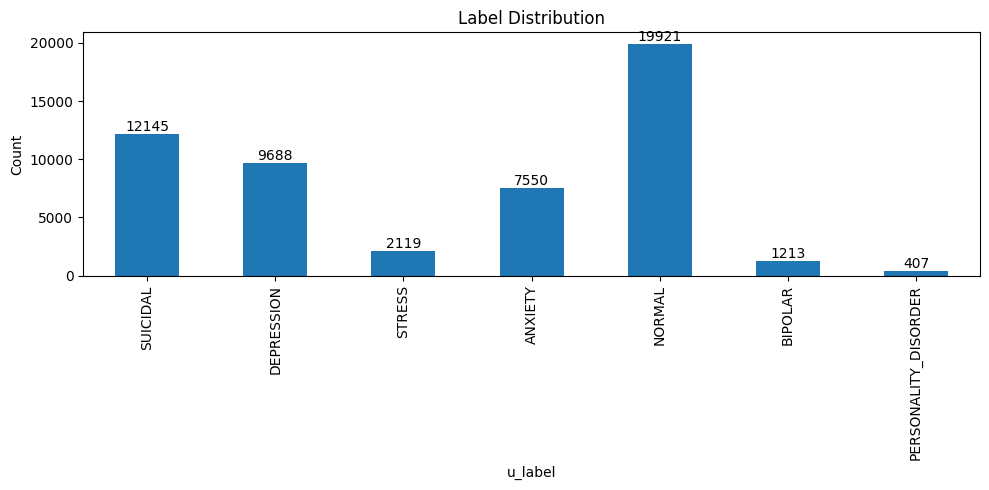

In [ ]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "MentalHealth_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.602832
test     0.198895
val      0.198273
Name: proportion, dtype: float64
Saved → ./02_mini4oLabel/outputs/MentalHealth_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [ ]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [ ]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [ ]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml   = df_val_ml["text_ml"].tolist()
X_test_ml  = df_test_ml["text_ml"].tolist()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

# TF-IDF (no stop_words param — already removed in ml_preprocess)
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_val_tfidf   = tfidf.transform(X_val_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f"TF-IDF: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = tfidf.get_feature_names_out()

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

TF-IDF: train=(31976, 10000), val=(10517, 10000), test=(10550, 10000)
ML splits: train=31976, val=10517, test=10550


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.7064 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.7349 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
LR tuning: 311.0s | Best F1=0.7349


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
                      precision    recall  f1-score   support

             ANXIETY     0.7500    0.7033    0.7259      1510
             BIPOLAR     0.6000    0.7469    0.6655       245
          DEPRESSION     0.6152    0.6301    0.6226      1949
              NORMAL     0.8393    0.7919    0.8149      3897
PERSONALITY_DISORDER     0.1429    0.3146    0.1965        89
              STRESS     0.3466    0.5902    0.4367       427
            SUICIDAL     0.8052    0.7390    0.7707      2433

            accuracy                         0.7239     10550
           macro avg     0.5856    0.6451    0.6047     10550
        weighted avg     0.7459    0.7239    0.7324     10550

Weighted F1: 0.7323  95% CI [0.7240, 0.7407]
Saved → ./02_mini4oLabel/outputs/Logistic_Regression_confusion_matrix.png


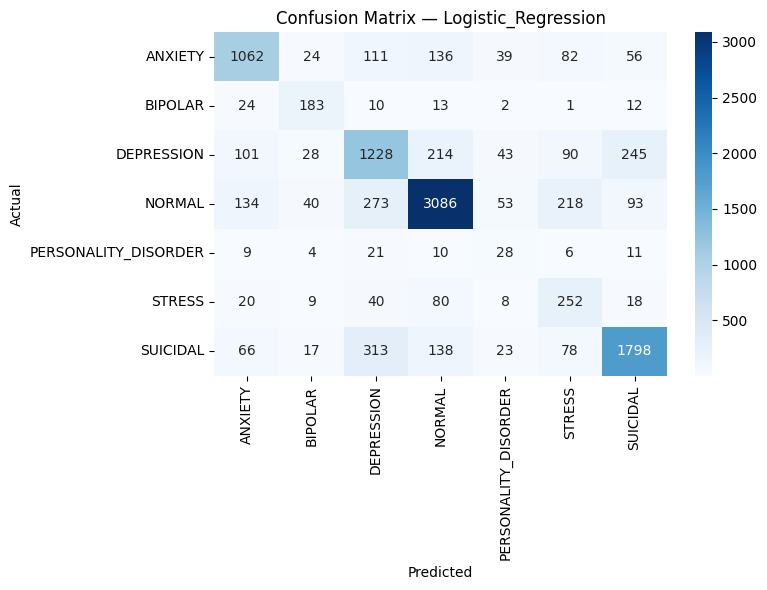

Macro AUC: 0.9298  95% CI [0.9242, 0.9349]
Saved → ./02_mini4oLabel/outputs/Logistic_Regression_roc_curve.png


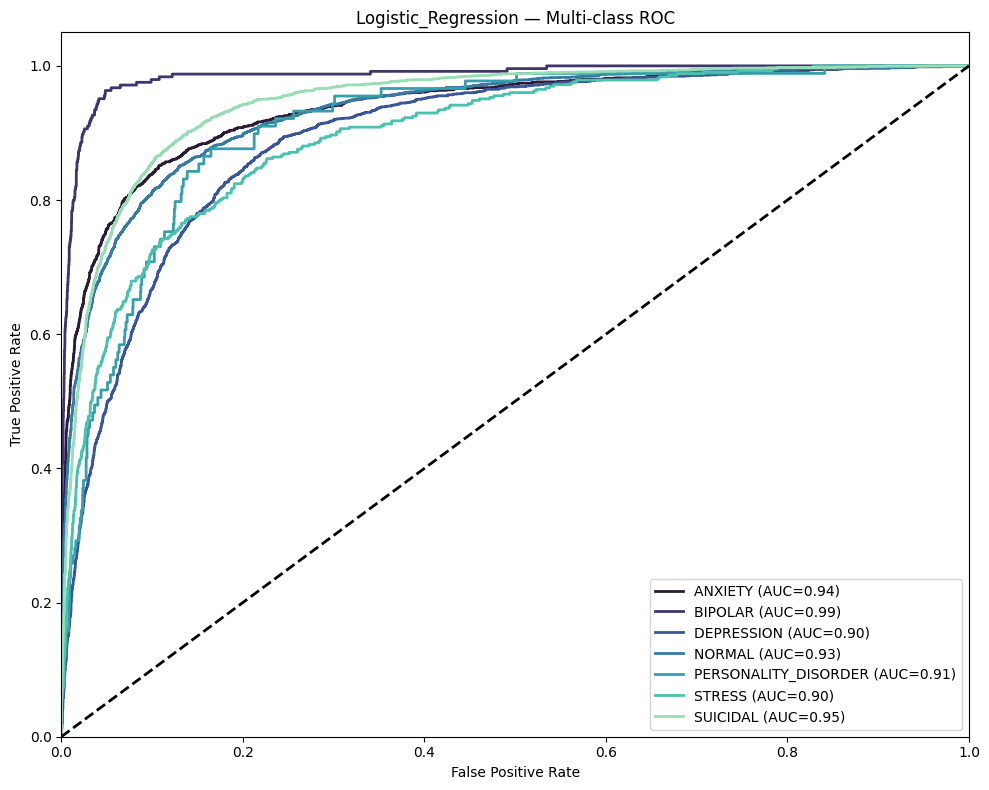

In [ ]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → ./02_mini4oLabel/outputs/logistic_regression_feature_importance.png


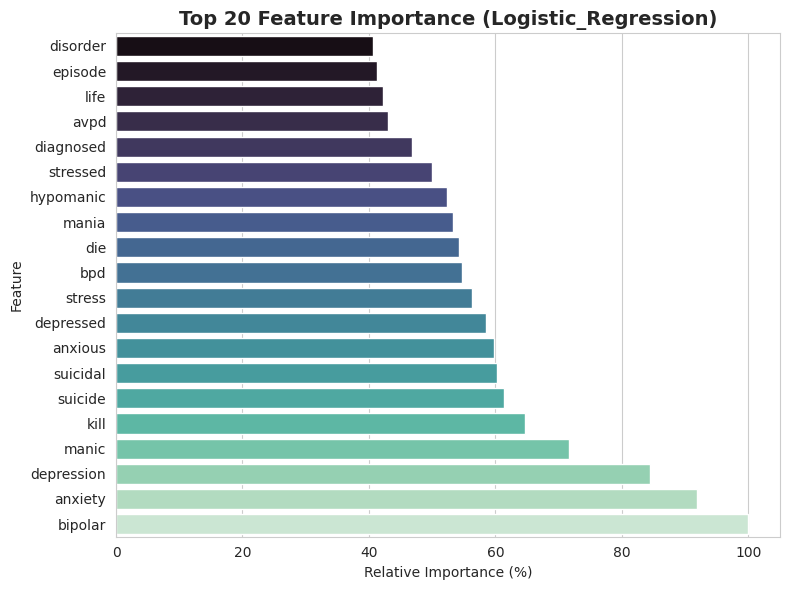

In [ ]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 SVM

### Step 1: Hyperparameter Tuning

In [ ]:
### Step 1: Hyperparameter Tuning

RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "class_weight": ["balanced", None],
        "gamma": ["scale"],
    }

    best_f1_svm, best_params_svm, best_model_svm = 0, None, None

    for C, kernel, class_weight, gamma in product(
        svm_grid["C"], svm_grid["kernel"],
        svm_grid["class_weight"], svm_grid["gamma"]
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, class_weight=class_weight,
                gamma=gamma, random_state=RANDOM_STATE, probability=False,
            )
            model.fit(X_train_tfidf, y_train_ml)
            y_val_pred = model.predict(X_val_tfidf)
            f1 = f1_score(y_val_ml, y_val_pred, average="weighted")

            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel,
                                   "class_weight": class_weight, "gamma": gamma}
                best_model_svm = model
                print(f"  New best F1: {f1:.4f} | {best_params_svm}")

        except Exception as e:
            print(f"  Skipping: {e}")

    # Retrain best config with probability=True for predict_proba
    print("\nRetraining best SVM with probability=True...")
    best_model_svm = SVC(
        **best_params_svm,
        random_state=RANDOM_STATE, probability=True,
    )
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    elapsed = time.time() - start
    print(f"\nBest SVM: F1={best_f1_svm:.4f} in {elapsed:.1f}s")
    print(f"Params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
    print(f"Saved best SVM model to: {MODEL_PATHS['svm']['model']}")
else:
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"]) as f:
        best_params_svm = json.load(f)
    print(f"Loaded saved SVM model. Params: {best_params_svm}")


Tuning SVM...
  New best F1: 0.7162 | {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.7385 | {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.7414 | {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}
  New best F1: 0.7422 | {'C': 1, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma': 'scale'}

Retraining best SVM with probability=True...

Best SVM: F1=0.7422 in 10167.4s
Params: {'C': 1, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma': 'scale'}
Saved best SVM model to: ./02_mini4oLabel/outputs/best_svm_model.joblib


### Step 2: Model Evaluation


Evaluation: SVM
                      precision    recall  f1-score   support

             ANXIETY     0.7528    0.7179    0.7349      1510
             BIPOLAR     0.7487    0.6082    0.6712       245
          DEPRESSION     0.5923    0.6901    0.6374      1949
              NORMAL     0.8133    0.8437    0.8282      3897
PERSONALITY_DISORDER     0.4286    0.0337    0.0625        89
              STRESS     0.4881    0.3372    0.3989       427
            SUICIDAL     0.8026    0.7571    0.7792      2433

            accuracy                         0.7445     10550
           macro avg     0.6609    0.5697    0.5875     10550
        weighted avg     0.7434    0.7445    0.7408     10550

Weighted F1: 0.7407  95% CI [0.7319, 0.7495]
Saved → ./02_mini4oLabel/outputs/SVM_confusion_matrix.png


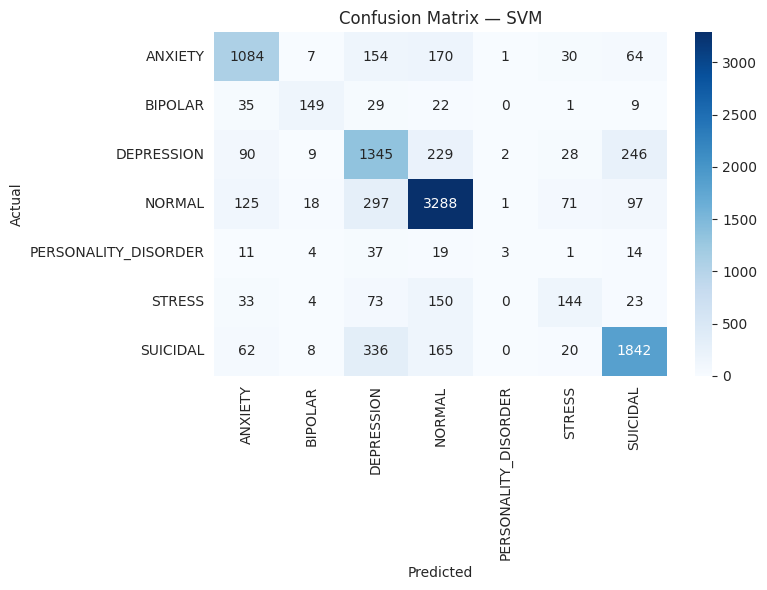

Macro AUC: 0.9330  95% CI [0.9275, 0.9378]
Saved → ./02_mini4oLabel/outputs/SVM_roc_curve.png


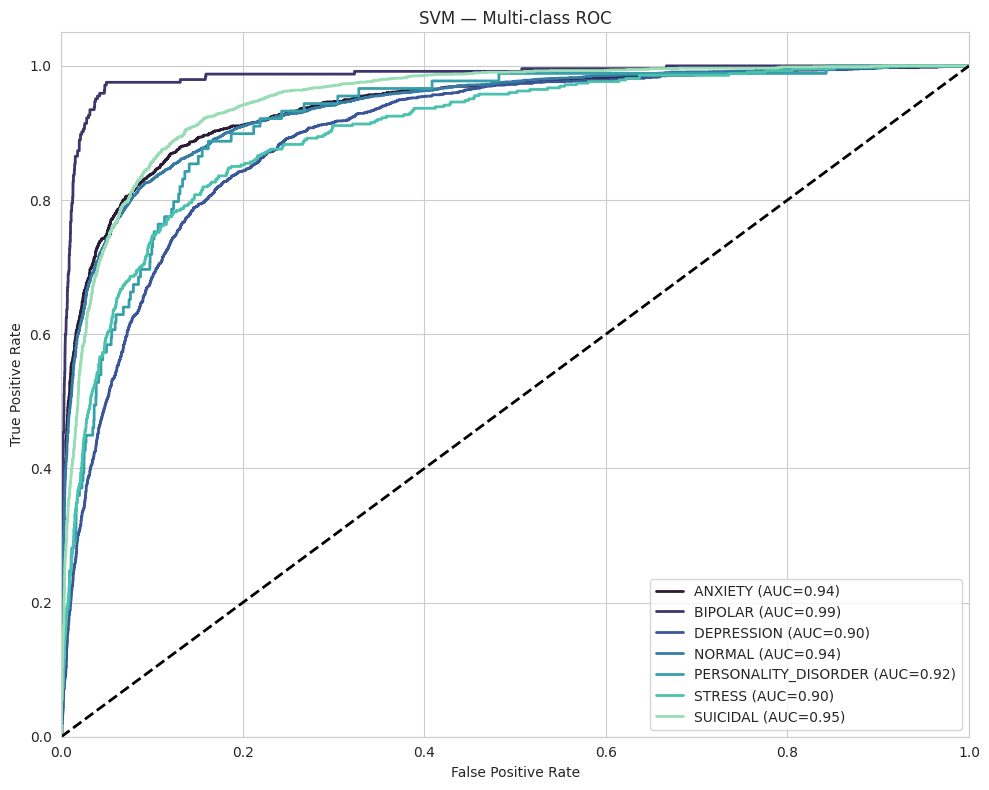

In [ ]:
evaluate_ml(best_model_svm, X_test_tfidf, y_test_ml, "SVM")

### Step 3: Model Interpretation

In [ ]:
# if best_model_svm.kernel == "linear" and hasattr(best_model_svm, "coef_"):
#     # Linear kernel: use coefficient weights directly (fast)
#     importances_svm = np.abs(best_model_svm.coef_).mean(axis=0)
#     if hasattr(importances_svm, "A1"):  # sparse matrix → flat array
#         importances_svm = importances_svm.A1
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")
# else:
#     # Non-linear kernel: permutation importance (slower)
#     print(f"Kernel='{best_model_svm.kernel}' — using permutation importance...")

#     max_samples = 1000
#     n_val = X_val_tfidf.shape[0]

#     if n_val > max_samples:
#         rng = np.random.RandomState(RANDOM_STATE)
#         idx = rng.choice(n_val, size=max_samples, replace=False)
#         X_perm = X_val_tfidf[idx]
#         y_perm = y_val_ml.iloc[idx] if hasattr(y_val_ml, "iloc") else y_val_ml[idx]
#     else:
#         X_perm = X_val_tfidf
#         y_perm = y_val_ml

#     print(f"Permutation importance on {X_perm.shape[0]} samples...")
#     start = time.time()

#     result = permutation_importance(
#         best_model_svm, X_perm, y_perm,
#         n_repeats=5, random_state=RANDOM_STATE,
#         n_jobs=-1, scoring="f1_weighted",
#     )

#     print(f"Done in {time.time() - start:.1f}s")

#     importances_svm = result.importances_mean.clip(min=0)
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [11:24<00:00,  4.22s/it]


RF tuning: 684.3s | Best F1=0.7061
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
                      precision    recall  f1-score   support

             ANXIETY     0.6475    0.7252    0.6842      1510
             BIPOLAR     0.6519    0.7184    0.6835       245
          DEPRESSION     0.5914    0.5695    0.5802      1949
              NORMAL     0.8352    0.7775    0.8053      3897
PERSONALITY_DISORDER     0.0000    0.0000    0.0000        89
              STRESS     0.3853    0.2084    0.2705       427
            SUICIDAL     0.6919    0.8113    0.7469      2433

            accuracy                         0.7084     10550
           macro avg     0.5433    0.5443    0.5387     10550
        weighted avg     0.7007    0.7084    0.7017     10550

Weighted F1: 0.7017  95% CI [0.6924, 0.7105]
Saved → ./02_mini4oLabel/outputs/RandomForest_confusion_matrix.png


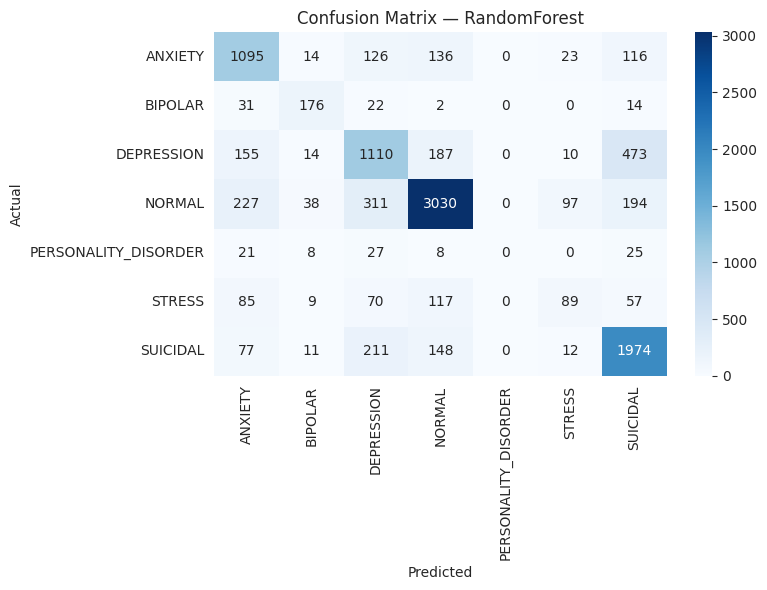

Macro AUC: 0.9107  95% CI [0.9043, 0.9169]
Saved → ./02_mini4oLabel/outputs/RandomForest_roc_curve.png


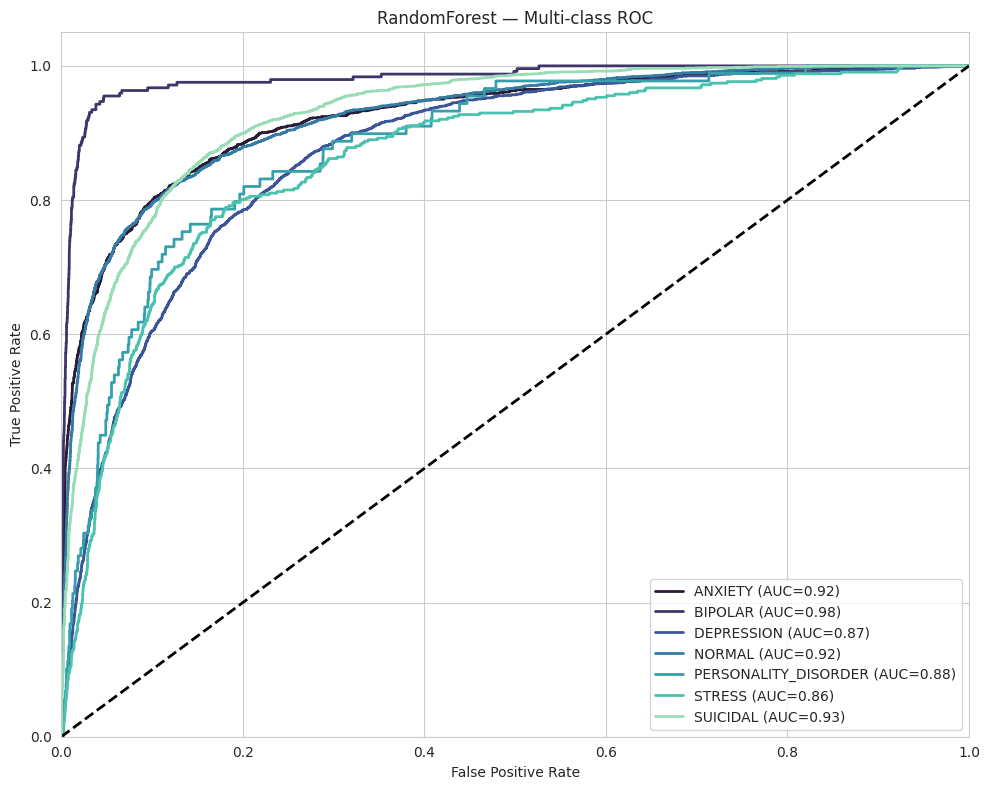

In [ ]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → ./02_mini4oLabel/outputs/randomforest_feature_importance.png


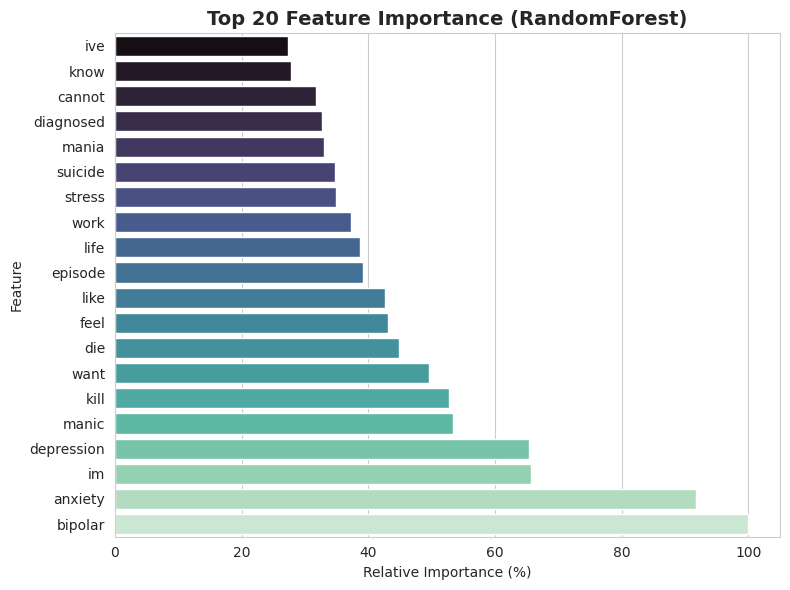

,Feature,Importance,Scaled
1120,bipolar,0.019891,100.000000
630,anxiety,0.018237,91.683799
4512,im,0.013056,65.636090
2451,depression,0.012989,65.301501
5431,manic,0.010626,53.420370
5001,kill,0.010487,52.723633
9651,want,0.009866,49.602456
2550,die,0.008927,44.879231
3469,feel,0.008579,43.127754
5209,like,0.008473,42.595014


In [ ]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [46:31<00:00, 58.16s/it]

LGBM tuning: 2791.6s | Best F1=0.7454
Best params: {'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': None, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: LightGBM
                      precision    recall  f1-score   support

             ANXIETY     0.7418    0.7364    0.7391      1510
             BIPOLAR     0.6667    0.7673    0.7135       245
          DEPRESSION     0.5983    0.6603    0.6278      1949
              NORMAL     0.8607    0.8009    0.8297      3897
PERSONALITY_DISORDER     0.3333    0.0449    0.0792        89
              STRESS     0.4039    0.4379    0.4202       427
            SUICIDAL     0.7723    0.7990    0.7855      2433

            accuracy                         0.7434     10550
           macro avg     0.6253    0.6067    0.5993     10550
        weighted avg     0.7474    0.7434    0.7436     10550

Weighted F1: 0.7438  95% CI [0.7353, 0.7517]
Saved → ./02_mini4oLabel/outputs/LightGBM_confusion_matrix.png


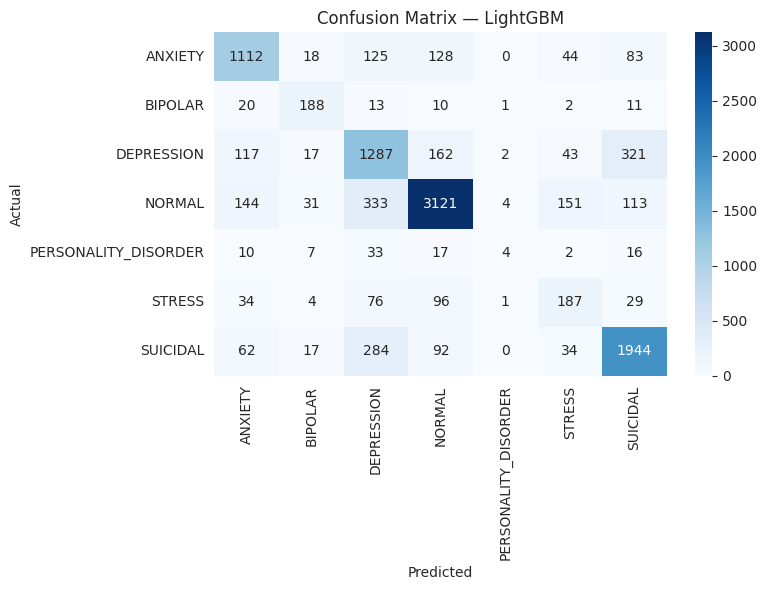

Macro AUC: 0.9301  95% CI [0.9248, 0.9350]
Saved → ./02_mini4oLabel/outputs/LightGBM_roc_curve.png


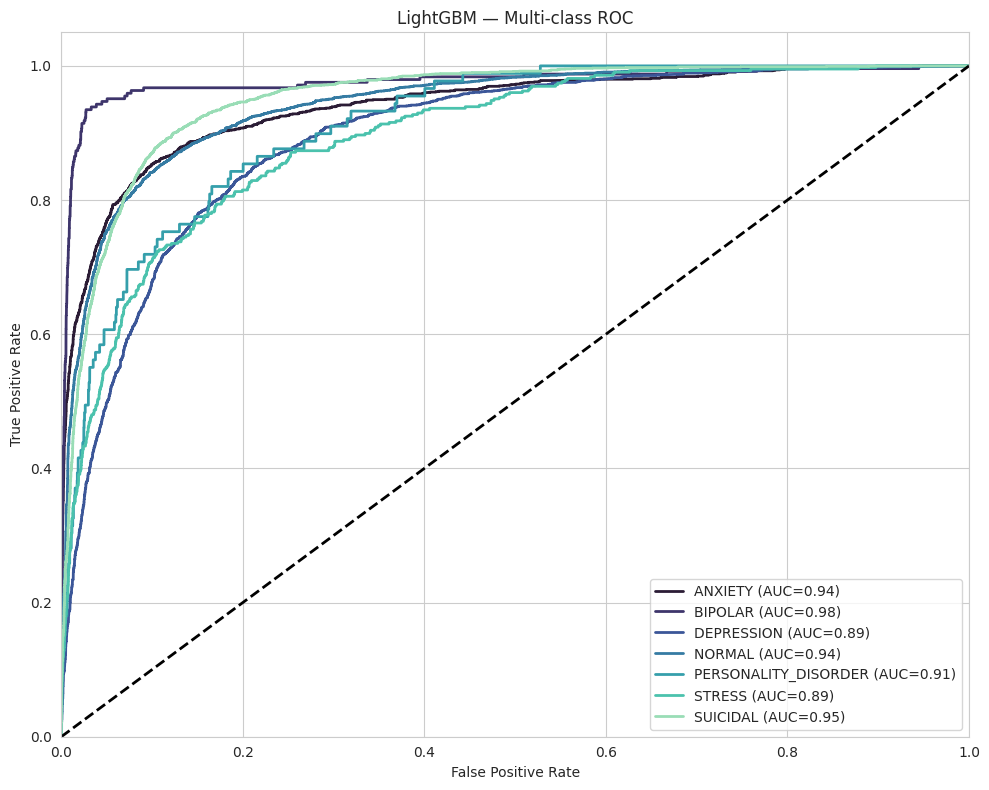

In [ ]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → ./02_mini4oLabel/outputs/lightgbm_feature_importance.png


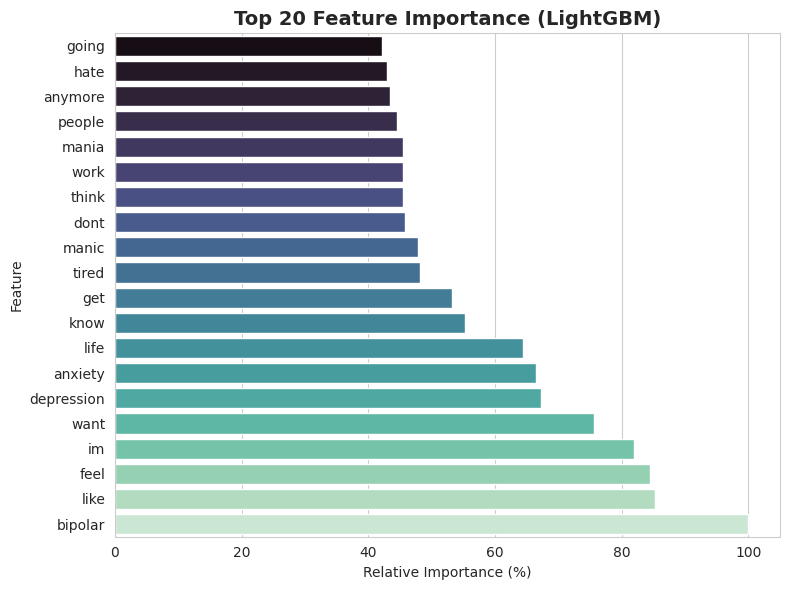

,Feature,Importance,Scaled
1120,bipolar,382,100.000000
5209,like,326,85.340314
3469,feel,323,84.554974
4512,im,313,81.937173
9651,want,289,75.654450
2451,depression,257,67.277487
630,anxiety,254,66.492147
5187,life,246,64.397906
5033,know,211,55.235602
3887,get,203,53.141361


In [ ]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [ ]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
svm_pred  = best_model_svm.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
svm_proba  = best_model_svm.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_svm.classes_)
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["svm_pred"]      = svm_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"]  = svm_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → ./02_mini4oLabel/outputs/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)

train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=31976, val=10517, test=10550
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([31976, 200]), val=torch.Size([10517, 200]), test=torch.Size([10550, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_gru, best_params_gru, best_gru = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.9197 | Val F1=0.1103 | Val Acc=0.1834
  Epoch 2/20 | Loss=1.8499 | Val F1=0.3015 | Val Acc=0.3967
  Epoch 3/20 | Loss=1.5766 | Val F1=0.5684 | Val Acc=0.5739
  Epoch 4/20 | Loss=1.2230 | Val F1=0.6076 | Val Acc=0.5793
  Epoch 5/20 | Loss=0.9813 | Val F1=0.6810 | Val Acc=0.6664
  Epoch 6/20 | Loss=0.7675 | Val F1=0.6864 | Val Acc=0.6566
  Epoch 7/20 | Loss=0.5958 | Val F1=0.7070 | Val Acc=0.6926
  Epoch 8/20 | Loss=0.4598 | Val F1=0.7054 | Val Acc=0.6869
  Epoch 9/20 | Loss=0.3642 | Val F1=0.6975 | Val Acc=0.6859
  Epoch 10/20 | Loss=0.3108 | Val F1=0.7144 | Val Acc=0.7063
  Epoch 11/20 | Loss=0.2320 | Val F1=0.7120 | Val Acc=0.7095
  Epoch 12/20 | Loss=0.1800 | Val F1=0.7161 | Val Acc=0.7125
  Epoch 13/20 | Loss=0.1556 | Val F1=0.7108 | Val Acc=0.7089
  Epoch 14/20 | Loss=0.1199 | Val F1=0.7098 | Val Acc=0.7051
  Epoch 15/20 | Loss=0.1229 | Val F1=0.7118 | Val Acc=0.7112
  Epoch 16/20 | Loss=0.0882 | Val F1=0.7097 | Val Acc=0.7089


GRU Random Search:  10%|█         | 1/10 [00:54<08:07, 54.14s/it]

  Epoch 17/20 | Loss=0.0730 | Val F1=0.7063 | Val Acc=0.6980
  Early stopping at epoch 17.
  Epoch 1/20 | Loss=1.9319 | Val F1=0.2444 | Val Acc=0.3731
  Epoch 2/20 | Loss=1.8981 | Val F1=0.2707 | Val Acc=0.3875
  Epoch 3/20 | Loss=1.8496 | Val F1=0.3284 | Val Acc=0.3005
  Epoch 4/20 | Loss=1.7442 | Val F1=0.4403 | Val Acc=0.4639
  Epoch 5/20 | Loss=1.6911 | Val F1=0.4606 | Val Acc=0.4956
  Epoch 6/20 | Loss=1.6282 | Val F1=0.4873 | Val Acc=0.5070
  Epoch 7/20 | Loss=1.5672 | Val F1=0.4940 | Val Acc=0.4729
  Epoch 8/20 | Loss=1.4895 | Val F1=0.5124 | Val Acc=0.5027
  Epoch 9/20 | Loss=1.4143 | Val F1=0.5179 | Val Acc=0.5417
  Epoch 10/20 | Loss=1.3409 | Val F1=0.5340 | Val Acc=0.5349
  Epoch 11/20 | Loss=1.2289 | Val F1=0.5539 | Val Acc=0.5709
  Epoch 12/20 | Loss=1.1505 | Val F1=0.5938 | Val Acc=0.6050
  Epoch 13/20 | Loss=1.1050 | Val F1=0.5809 | Val Acc=0.5529
  Epoch 14/20 | Loss=1.0352 | Val F1=0.6002 | Val Acc=0.5452
  Epoch 15/20 | Loss=0.9984 | Val F1=0.6325 | Val Acc=0.6166
  E

...

  Epoch 20/20 | Loss=0.8815 | Val F1=0.6509 | Val Acc=0.6454
  Epoch 1/20 | Loss=1.9244 | Val F1=0.2561 | Val Acc=0.3807
  Epoch 2/20 | Loss=1.8749 | Val F1=0.2772 | Val Acc=0.3850
  Epoch 3/20 | Loss=1.7744 | Val F1=0.4249 | Val Acc=0.4492
  Epoch 4/20 | Loss=1.6718 | Val F1=0.4814 | Val Acc=0.5137
  Epoch 5/20 | Loss=1.5584 | Val F1=0.5078 | Val Acc=0.5305
  Epoch 6/20 | Loss=1.3987 | Val F1=0.5184 | Val Acc=0.5332
  Epoch 7/20 | Loss=1.2851 | Val F1=0.5611 | Val Acc=0.5562
  Epoch 8/20 | Loss=1.1915 | Val F1=0.6125 | Val Acc=0.6071
  Epoch 9/20 | Loss=1.0937 | Val F1=0.6003 | Val Acc=0.6031
  Epoch 10/20 | Loss=1.0352 | Val F1=0.6407 | Val Acc=0.6249
  Epoch 11/20 | Loss=0.9601 | Val F1=0.6526 | Val Acc=0.6272
  Epoch 12/20 | Loss=0.8902 | Val F1=0.6558 | Val Acc=0.6170
  Epoch 13/20 | Loss=0.8230 | Val F1=0.6541 | Val Acc=0.6234
  Epoch 14/20 | Loss=0.7677 | Val F1=0.6744 | Val Acc=0.6437
  Epoch 15/20 | Loss=0.7147 | Val F1=0.6835 | Val Acc=0.6619
  Epoch 16/20 | Loss=0.6551 | Val

GRU Random Search:  90%|█████████ | 9/10 [08:28<01:00, 60.01s/it]

  Epoch 20/20 | Loss=0.5045 | Val F1=0.6935 | Val Acc=0.6711
  Epoch 1/20 | Loss=1.9430 | Val F1=0.0892 | Val Acc=0.1495
  Epoch 2/20 | Loss=1.9187 | Val F1=0.2746 | Val Acc=0.3909
  Epoch 3/20 | Loss=1.8955 | Val F1=0.2666 | Val Acc=0.3862
  Epoch 4/20 | Loss=1.8476 | Val F1=0.3176 | Val Acc=0.2837
  Epoch 5/20 | Loss=1.7597 | Val F1=0.3660 | Val Acc=0.3674
  Epoch 6/20 | Loss=1.7292 | Val F1=0.4108 | Val Acc=0.3760
  Epoch 7/20 | Loss=1.7079 | Val F1=0.4213 | Val Acc=0.4036
  Epoch 8/20 | Loss=1.6805 | Val F1=0.4584 | Val Acc=0.4753
  Epoch 9/20 | Loss=1.6559 | Val F1=0.4568 | Val Acc=0.4904
  Epoch 10/20 | Loss=1.6276 | Val F1=0.4649 | Val Acc=0.4864
  Epoch 11/20 | Loss=1.6007 | Val F1=0.4675 | Val Acc=0.4862
  Epoch 12/20 | Loss=1.5702 | Val F1=0.4681 | Val Acc=0.4736
  Epoch 13/20 | Loss=1.5445 | Val F1=0.4783 | Val Acc=0.4442
  Epoch 14/20 | Loss=1.5153 | Val F1=0.4956 | Val Acc=0.4747
  Epoch 15/20 | Loss=1.4818 | Val F1=0.4618 | Val Acc=0.4365
  Epoch 16/20 | Loss=1.4556 | Val

GRU Random Search: 100%|██████████| 10/10 [09:39<00:00, 57.94s/it]

  Epoch 20/20 | Loss=1.3523 | Val F1=0.4924 | Val Acc=0.4680
GRU tuning: 579.4s | Best F1=0.7161
Best params: {'embedding_dim': 170, 'hidden_dim': 355, 'lr': 0.0008562599671988812}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 83/83 [00:00<00:00, 179.79it/s]



Evaluation: GRU
                      precision    recall  f1-score   support

            SUICIDAL     0.7438    0.7661    0.7548      2433
          DEPRESSION     0.5407    0.6372    0.5850      1949
              STRESS     0.3002    0.3185    0.3091       427
             ANXIETY     0.7003    0.6947    0.6975      1510
              NORMAL     0.8604    0.7652    0.8100      3897
             BIPOLAR     0.6473    0.6816    0.6640       245
PERSONALITY_DISORDER     0.0833    0.0674    0.0745        89

            accuracy                         0.7058     10550
           macro avg     0.5537    0.5615    0.5564     10550
        weighted avg     0.7173    0.7058    0.7097     10550

Weighted F1: 0.7096  95% CI [0.7012, 0.7183]
Saved → ./02_mini4oLabel/outputs/GRU_confusion_matrix.png


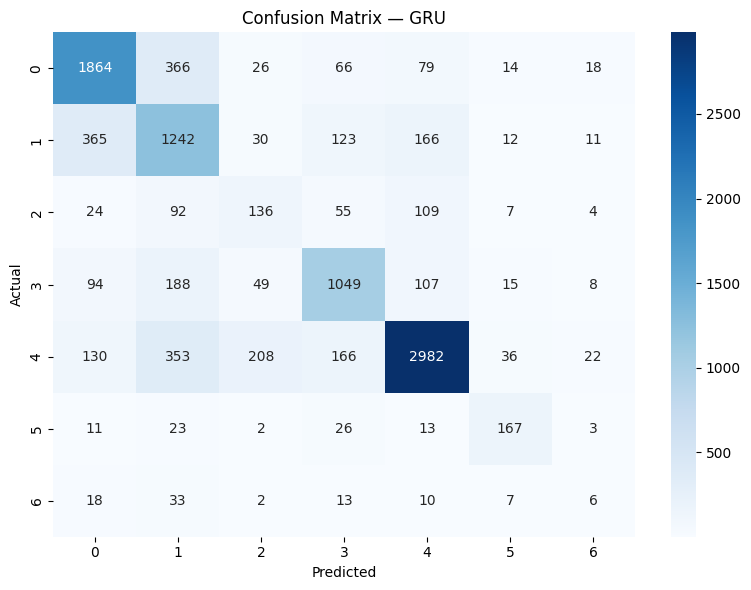

Macro AUC: 0.8697  95% CI [0.8593, 0.8810]
Saved → ./02_mini4oLabel/outputs/GRU_roc_curve.png


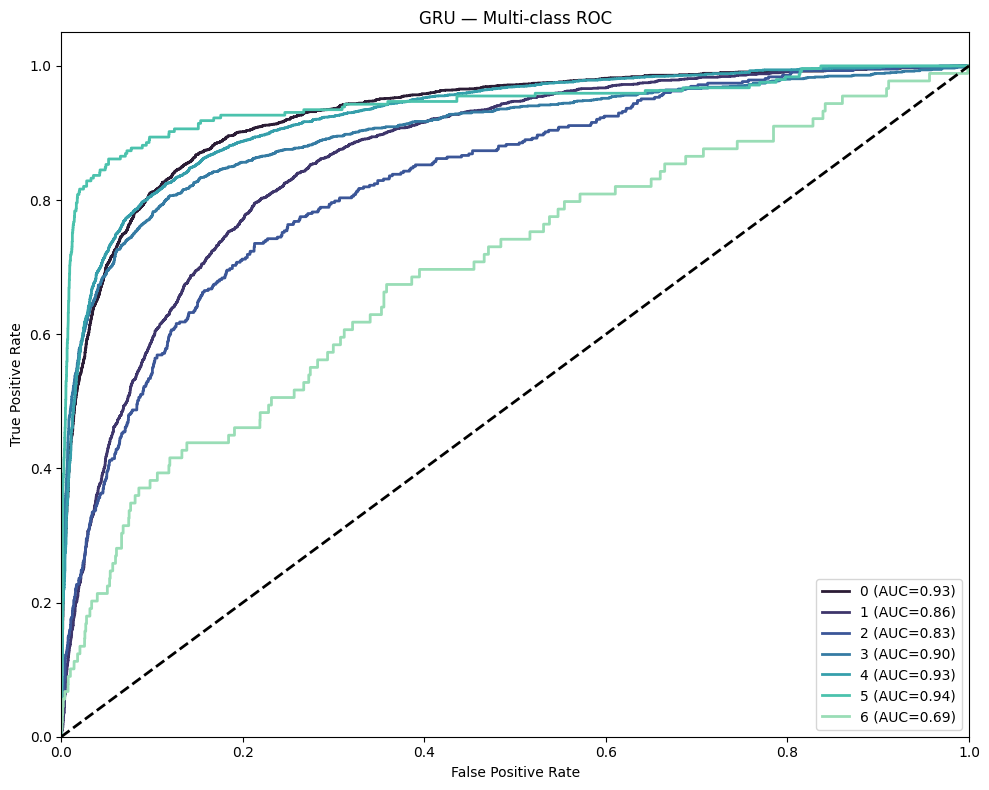

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_cnn, best_params_cnn, best_cnn = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.6345 | Val F1=0.6612 | Val Acc=0.6608
  Epoch 2/20 | Loss=1.1149 | Val F1=0.6965 | Val Acc=0.6788
  Epoch 3/20 | Loss=0.9042 | Val F1=0.7098 | Val Acc=0.6786
  Epoch 4/20 | Loss=0.7444 | Val F1=0.7249 | Val Acc=0.7107
  Epoch 5/20 | Loss=0.6310 | Val F1=0.7353 | Val Acc=0.7345
  Epoch 6/20 | Loss=0.5537 | Val F1=0.7382 | Val Acc=0.7383
  Epoch 7/20 | Loss=0.4886 | Val F1=0.7336 | Val Acc=0.7253
  Epoch 8/20 | Loss=0.4211 | Val F1=0.7365 | Val Acc=0.7320
  Epoch 9/20 | Loss=0.3744 | Val F1=0.7360 | Val Acc=0.7275
  Epoch 10/20 | Loss=0.3386 | Val F1=0.7299 | Val Acc=0.7260
  Epoch 11/20 | Loss=0.3059 | Val F1=0.7427 | Val Acc=0.7420
  Epoch 12/20 | Loss=0.2733 | Val F1=0.7384 | Val Acc=0.7396
  Epoch 13/20 | Loss=0.2373 | Val F1=0.7297 | Val Acc=0.7254
  Epoch 14/20 | Loss=0.2104 | Val F1=0.7376 | Val Acc=0.7357
  Epoch 15/20 | Loss=0.1925 | Val F1=0.7385 | Val Acc=0.7373


CNN Random Search:  10%|█         | 1/10 [00:23<03:33, 23.72s/it]

  Epoch 16/20 | Loss=0.1780 | Val F1=0.7399 | Val Acc=0.7419
  Early stopping at epoch 16.
  Epoch 1/20 | Loss=1.8493 | Val F1=0.5478 | Val Acc=0.5333
  Epoch 2/20 | Loss=1.4623 | Val F1=0.6196 | Val Acc=0.6100
  Epoch 3/20 | Loss=1.2306 | Val F1=0.6440 | Val Acc=0.6192
  Epoch 4/20 | Loss=1.0726 | Val F1=0.6756 | Val Acc=0.6580
  Epoch 5/20 | Loss=0.9729 | Val F1=0.6882 | Val Acc=0.6670
  Epoch 6/20 | Loss=0.8980 | Val F1=0.6948 | Val Acc=0.6698
  Epoch 7/20 | Loss=0.8203 | Val F1=0.7035 | Val Acc=0.6903
  Epoch 8/20 | Loss=0.7637 | Val F1=0.7161 | Val Acc=0.7122
  Epoch 9/20 | Loss=0.7133 | Val F1=0.7134 | Val Acc=0.7048
  Epoch 10/20 | Loss=0.6732 | Val F1=0.7233 | Val Acc=0.7143
  Epoch 11/20 | Loss=0.6404 | Val F1=0.7224 | Val Acc=0.7135
  Epoch 12/20 | Loss=0.5959 | Val F1=0.7300 | Val Acc=0.7247
  Epoch 13/20 | Loss=0.5757 | Val F1=0.7302 | Val Acc=0.7260
  Epoch 14/20 | Loss=0.5502 | Val F1=0.7339 | Val Acc=0.7306
  Epoch 15/20 | Loss=0.5244 | Val F1=0.7362 | Val Acc=0.7339
  E

...

  Epoch 20/20 | Loss=0.4058 | Val F1=0.7440 | Val Acc=0.7447
  Epoch 1/20 | Loss=1.7791 | Val F1=0.6063 | Val Acc=0.6067
  Epoch 2/20 | Loss=1.2626 | Val F1=0.6486 | Val Acc=0.6238
  Epoch 3/20 | Loss=1.0192 | Val F1=0.6970 | Val Acc=0.6805
  Epoch 4/20 | Loss=0.8694 | Val F1=0.7094 | Val Acc=0.6961
  Epoch 5/20 | Loss=0.7609 | Val F1=0.7066 | Val Acc=0.6990
  Epoch 6/20 | Loss=0.6844 | Val F1=0.7271 | Val Acc=0.7190
  Epoch 7/20 | Loss=0.6207 | Val F1=0.7355 | Val Acc=0.7305
  Epoch 8/20 | Loss=0.5625 | Val F1=0.7285 | Val Acc=0.7170
  Epoch 9/20 | Loss=0.5249 | Val F1=0.7430 | Val Acc=0.7373
  Epoch 10/20 | Loss=0.4779 | Val F1=0.7402 | Val Acc=0.7363
  Epoch 11/20 | Loss=0.4390 | Val F1=0.7419 | Val Acc=0.7403
  Epoch 12/20 | Loss=0.4281 | Val F1=0.7420 | Val Acc=0.7393
  Epoch 13/20 | Loss=0.3945 | Val F1=0.7390 | Val Acc=0.7343
  Epoch 14/20 | Loss=0.3659 | Val F1=0.7430 | Val Acc=0.7438
  Epoch 15/20 | Loss=0.3522 | Val F1=0.7463 | Val Acc=0.7446
  Epoch 16/20 | Loss=0.3238 | Val

CNN Random Search:  90%|█████████ | 9/10 [03:53<00:27, 27.30s/it]

  Epoch 20/20 | Loss=0.2581 | Val F1=0.7476 | Val Acc=0.7493
  Epoch 1/20 | Loss=1.9414 | Val F1=0.5194 | Val Acc=0.4981
  Epoch 2/20 | Loss=1.6521 | Val F1=0.5640 | Val Acc=0.5572
  Epoch 3/20 | Loss=1.4475 | Val F1=0.6134 | Val Acc=0.5920
  Epoch 4/20 | Loss=1.3026 | Val F1=0.6323 | Val Acc=0.6145
  Epoch 5/20 | Loss=1.1920 | Val F1=0.6500 | Val Acc=0.6327
  Epoch 6/20 | Loss=1.1224 | Val F1=0.6589 | Val Acc=0.6483
  Epoch 7/20 | Loss=1.0559 | Val F1=0.6672 | Val Acc=0.6491
  Epoch 8/20 | Loss=0.9978 | Val F1=0.6787 | Val Acc=0.6599
  Epoch 9/20 | Loss=0.9493 | Val F1=0.6901 | Val Acc=0.6766
  Epoch 10/20 | Loss=0.8975 | Val F1=0.6926 | Val Acc=0.6796
  Epoch 11/20 | Loss=0.8627 | Val F1=0.7025 | Val Acc=0.6885
  Epoch 12/20 | Loss=0.8174 | Val F1=0.7057 | Val Acc=0.6947
  Epoch 13/20 | Loss=0.7891 | Val F1=0.7110 | Val Acc=0.7003
  Epoch 14/20 | Loss=0.7626 | Val F1=0.7164 | Val Acc=0.7073
  Epoch 15/20 | Loss=0.7361 | Val F1=0.7106 | Val Acc=0.7012
  Epoch 16/20 | Loss=0.7188 | Val

CNN Random Search: 100%|██████████| 10/10 [04:22<00:00, 26.21s/it]

  Epoch 20/20 | Loss=0.6244 | Val F1=0.7258 | Val Acc=0.7199
CNN tuning: 262.1s | Best F1=0.7503
Best params: {'embedding_dim': 287, 'num_filters': 193, 'lr': 0.00018953847119167257}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 83/83 [00:00<00:00, 440.18it/s]



Evaluation: CNN
                      precision    recall  f1-score   support

            SUICIDAL     0.7646    0.8130    0.7880      2433
          DEPRESSION     0.6238    0.6501    0.6367      1949
              STRESS     0.4292    0.4262    0.4277       427
             ANXIETY     0.7328    0.7212    0.7270      1510
              NORMAL     0.8558    0.8147    0.8348      3897
             BIPOLAR     0.6593    0.7347    0.6950       245
PERSONALITY_DISORDER     0.3590    0.1573    0.2188        89

            accuracy                         0.7474     10550
           macro avg     0.6321    0.6167    0.6183     10550
        weighted avg     0.7483    0.7474    0.7470     10550

Weighted F1: 0.7469  95% CI [0.7392, 0.7555]
Saved → ./02_mini4oLabel/outputs/CNN_confusion_matrix.png


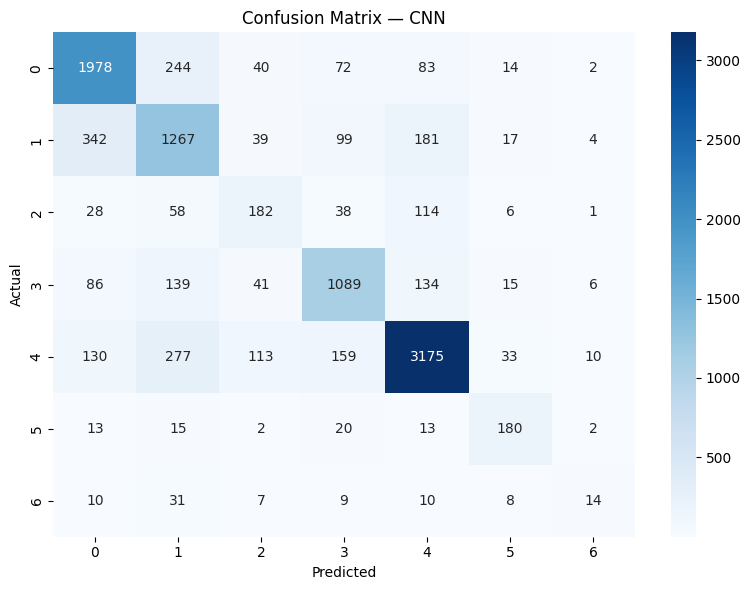

Macro AUC: 0.9273  95% CI [0.9201, 0.9337]
Saved → ./02_mini4oLabel/outputs/CNN_roc_curve.png


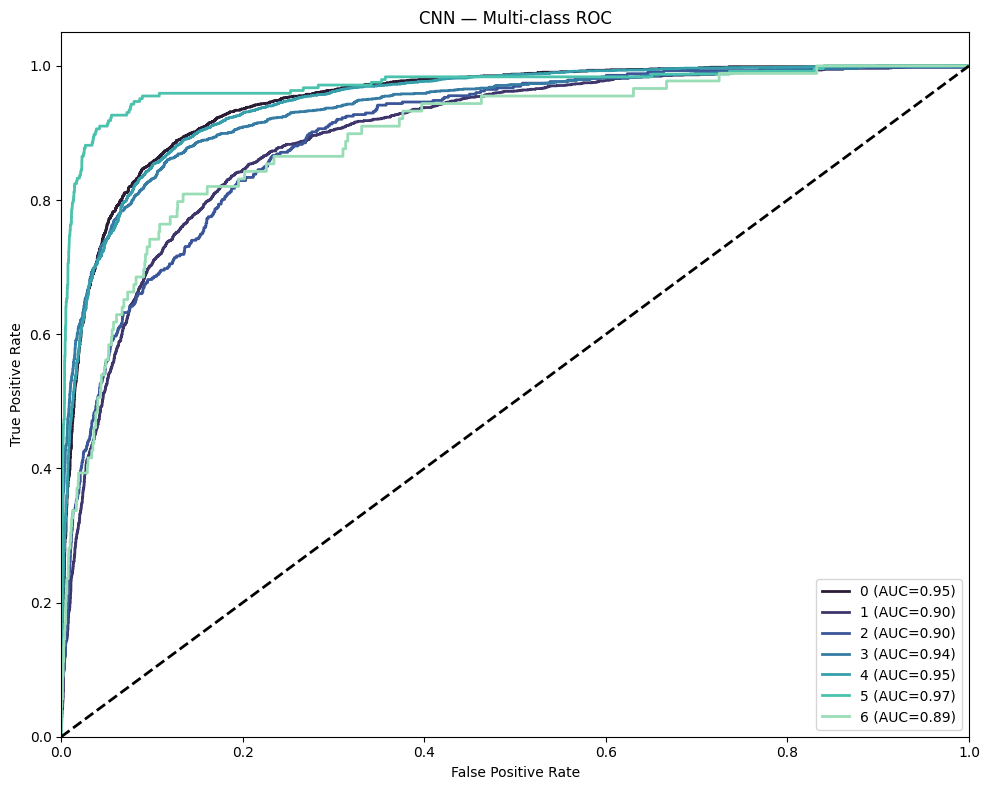

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

ALBERT tokens: train=torch.Size([31976, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.4742 | Val F1=0.7061
  Epoch 2/9 | Loss=0.8110 | Val F1=0.7712
  Epoch 3/9 | Loss=0.6124 | Val F1=0.7514
  Epoch 4/9 | Loss=0.4413 | Val F1=0.7820
  Epoch 5/9 | Loss=0.3062 | Val F1=0.7897
  Epoch 6/9 | Loss=0.2000 | Val F1=0.7921
  Epoch 7/9 | Loss=0.1188 | Val F1=0.7890
  Epoch 8/9 | Loss=0.0732 | Val F1=0.7880
  Epoch 9/9 | Loss=0.0550 | Val F1=0.7883
  Early stopping at epoch 9.


ALBERT Random Search: 100%|██████████| 10/10 [1:02:04<00:00, 372.43s/it]


ALBERT tuning: 3724.3s | Best F1=0.7930
Best params: {'lr': 1.7871371577780496e-05, 'epochs': 5, 'dropout': 0.0007927791888235614}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 83/83 [00:06<00:00, 11.95it/s]



Evaluation: ALBERT
                      precision    recall  f1-score   support

            SUICIDAL     0.8305    0.8118    0.8210      2433
          DEPRESSION     0.6609    0.7260    0.6919      1949
              STRESS     0.4401    0.6534    0.5259       427
             ANXIETY     0.7666    0.7636    0.7651      1510
              NORMAL     0.9134    0.8034    0.8549      3897
             BIPOLAR     0.6926    0.8367    0.7579       245
PERSONALITY_DISORDER     0.2663    0.5056    0.3488        89

            accuracy                         0.7775     10550
           macro avg     0.6529    0.7286    0.6808     10550
        weighted avg     0.7969    0.7775    0.7843     10550

Weighted F1: 0.7842  95% CI [0.7762, 0.7919]
Saved → ./02_mini4oLabel/outputs/ALBERT_confusion_matrix.png


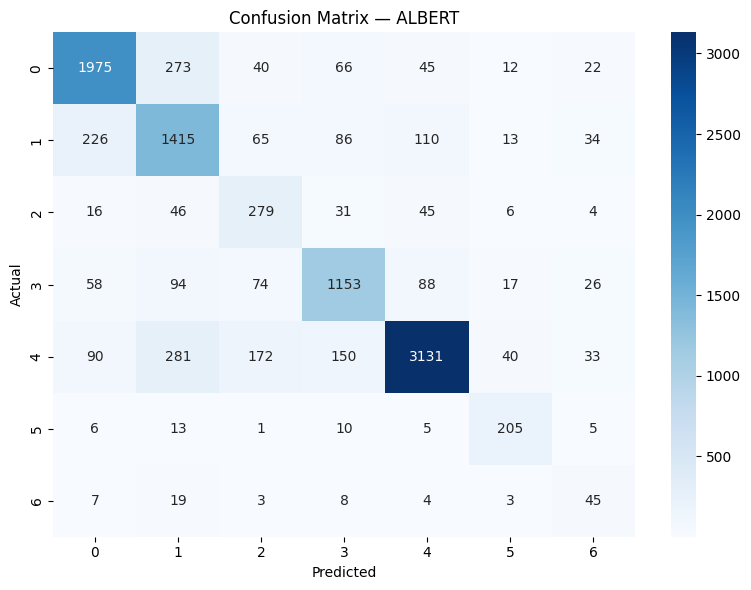

Macro AUC: 0.9569  95% CI [0.9534, 0.9601]
Saved → ./02_mini4oLabel/outputs/ALBERT_roc_curve.png


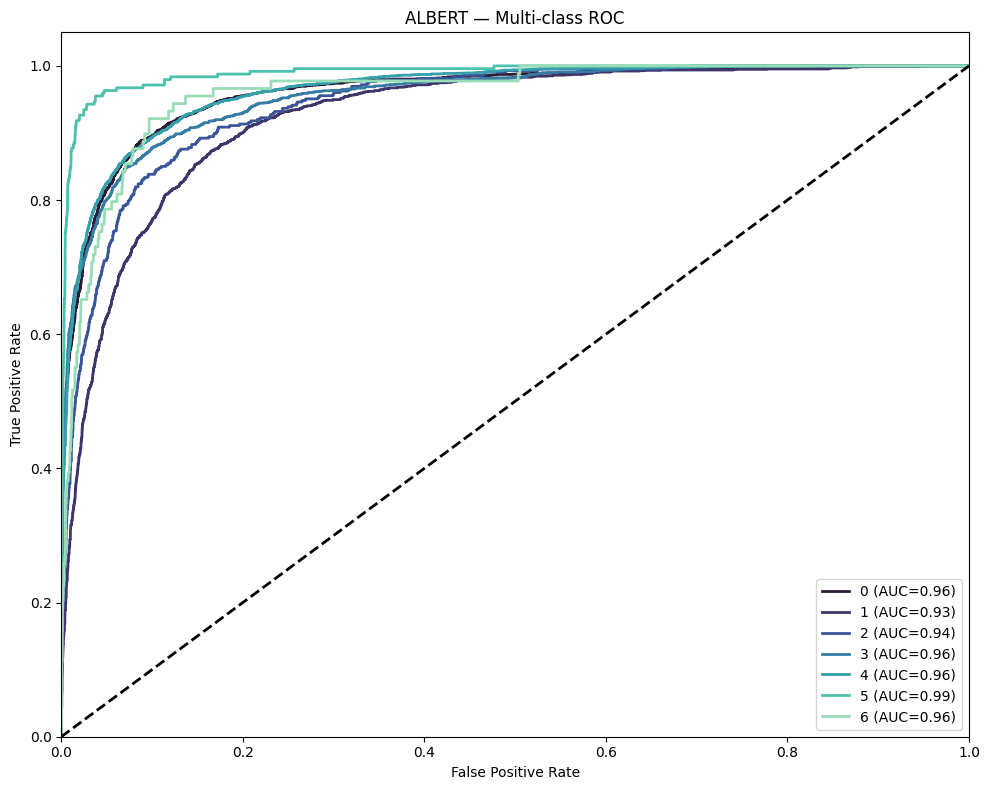

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-v1.1"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BioBERT tokens: train=torch.Size([31976, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        model.config.hidden_dropout_prob = hp["dropout"]
        model.config.attention_probs_dropout_prob = hp["dropout"]

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
else:
    print("Loading BioBERT from disk...")
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, num_labels=NUM_CLASSES,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.4935 | Val F1=0.6912
  Epoch 2/9 | Loss=0.8208 | Val F1=0.7570
  Epoch 3/9 | Loss=0.5726 | Val F1=0.7544
  Epoch 4/9 | Loss=0.4185 | Val F1=0.7631
  Epoch 5/9 | Loss=0.3017 | Val F1=0.7823
  Epoch 6/9 | Loss=0.2232 | Val F1=0.7806
  Epoch 7/9 | Loss=0.1680 | Val F1=0.7810
  Epoch 8/9 | Loss=0.1421 | Val F1=0.7804
  Early stopping at epoch 8.


BioBERT Random Search: 100%|██████████| 10/10 [46:58<00:00, 281.84s/it]


BioBERT tuning: 2818.4s | Best F1=0.7823
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 83/83 [00:03<00:00, 23.09it/s]



Evaluation: BioBERT
                      precision    recall  f1-score   support

            SUICIDAL     0.7974    0.8557    0.8255      2433
          DEPRESSION     0.6780    0.6675    0.6727      1949
              STRESS     0.4288    0.5995    0.5000       427
             ANXIETY     0.7811    0.7325    0.7560      1510
              NORMAL     0.8985    0.8083    0.8510      3897
             BIPOLAR     0.6246    0.8898    0.7340       245
PERSONALITY_DISORDER     0.2303    0.3933    0.2905        89

            accuracy                         0.7723     10550
           macro avg     0.6341    0.7067    0.6614     10550
        weighted avg     0.7866    0.7723    0.7769     10550

Weighted F1: 0.7769  95% CI [0.7689, 0.7847]
Saved → ./02_mini4oLabel/outputs/BioBERT_confusion_matrix.png


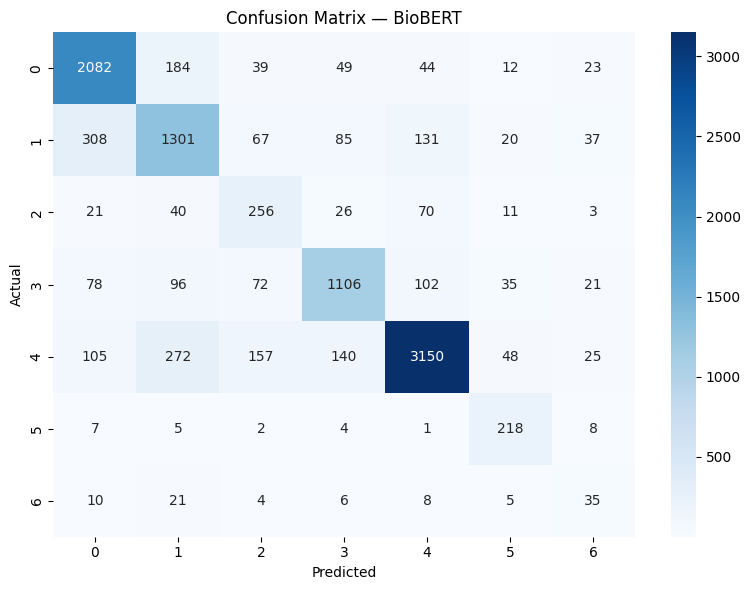

Macro AUC: 0.9492  95% CI [0.9440, 0.9537]
Saved → ./02_mini4oLabel/outputs/BioBERT_roc_curve.png


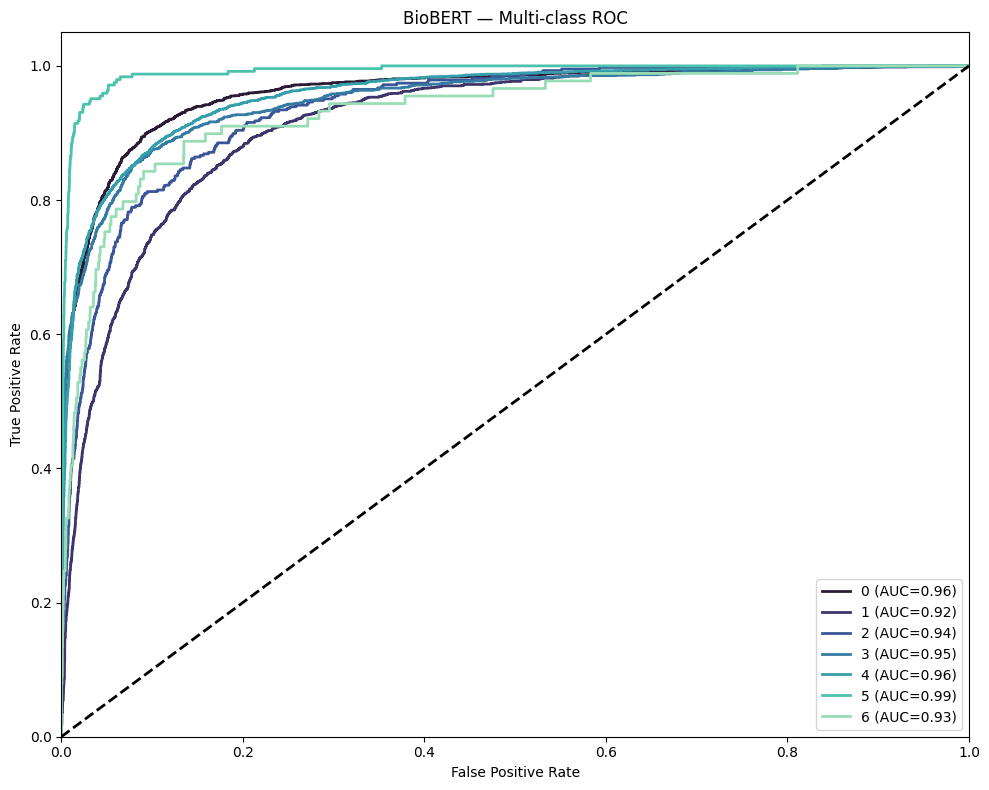

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → ./02_mini4oLabel/outputs/dl_models_predictions.csv


# 5. Model Comparison

In [12]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":      label_encoder.transform(df_merged["lr_pred"].values),
    "SVM":     label_encoder.transform(df_merged["svm_pred"].values),  # <-- add this
    "RF":      label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":    label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":     df_merged["gru_pred_id"].values,
    "CNN":     df_merged["cnn_pred_id"].values,
    "ALBERT":  df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 10550 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong  statistic        p_raw     winner_raw  p_corrected significant
     LR     SVM          7293      344      562        2351  51.974614 5.622285e-13       SVM > LR 1.574240e-11         Yes
     LR      RF          6626     1011      848        2065  14.117267 1.717598e-04        LR > RF 4.809275e-03         Yes
     LR    LGBM          7009      628      834        2079  28.744870 8.256834e-08      LGBM > LR 2.311914e-06         Yes
     LR     GRU          6388     1249     1058        1855  15.648028 7.629210e-05       LR > GRU 2.136179e-03         Yes
     LR     CNN          6818      819     1067        1846  32.348356 1.288662e-08       CNN > LR 3.608253e-07         Yes
     LR  ALBERT          6856      781     1347        1566 150.011748 1.723423e-34    ALBERT > LR 4.825584e-33         Yes
     LR BioBERT      